,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,9,15,2018,50000,1,1,0,15,1498,108,5,800000
1,3,14,2019,40000,1,0,1,17,1597,140,5,1000000
2,2,30,2017,20000,1,0,0,10,4951,395,4,2500000
3,6,42,2020,30000,0,1,2,23,1248,74,5,600000
4,4,41,2016,60000,0,0,1,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...,...,...,...,...
95,7,11,2019,22000,0,0,0,16,1950,191,5,2900000
96,9,29,2017,38000,0,1,1,13,2755,171,7,1400000
97,2,18,2018,26000,1,1,2,18,1497,121,5,750000
98,4,50,2019,24000,1,0,1,17,1497,113,5,850000


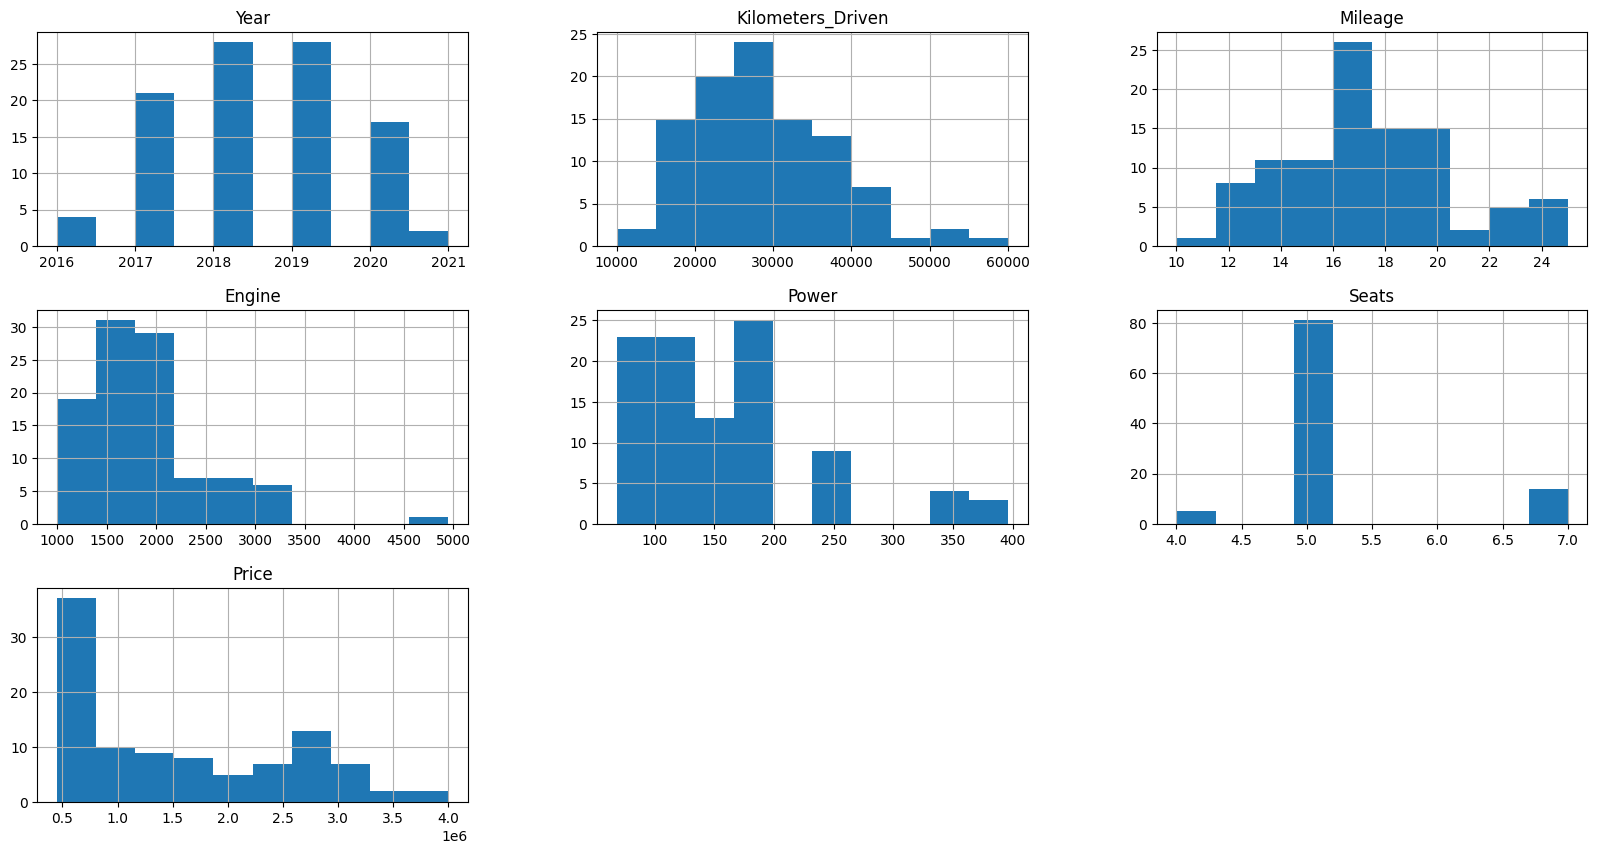

In [ ]:
# Second hand car price prediction using Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


# load data into pandas dataframe, from collab files, downloaded from kaggle
df = pd.read_csv("/cars.csv")

# printing first 5 rows
df.head()

# drop rows/columns with missing values, also dropping car_id column
df.dropna(inplace=True)
df=df.drop("Car_ID",axis=1)

# data plotting
df.hist(figsize=(20,10))
#col=['Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type',
#       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',]
#for i in col :
#    plt.figure(figsize=(20,10))
#    sns.histplot(df, y=i, hue="Price",bins=100,palette="BuPu")
#    print(f"**********{i}**********")
#    plt.show()

# label encode: converting text into numerical values
mycol=['Brand', 'Model','Fuel_Type','Transmission','Owner_Type']
label_encoder = LabelEncoder()
for col in mycol:
    df[col] = label_encoder.fit_transform(df[col])

df

In [ ]:
X=df.drop("Price",axis=1)
X

,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,9,15,2018,50000,1,1,0,15,1498,108,5
1,3,14,2019,40000,1,0,1,17,1597,140,5
2,2,30,2017,20000,1,0,0,10,4951,395,4
3,6,42,2020,30000,0,1,2,23,1248,74,5
4,4,41,2016,60000,0,0,1,18,1999,194,5
...,...,...,...,...,...,...,...,...,...,...,...
95,7,11,2019,22000,0,0,0,16,1950,191,5
96,9,29,2017,38000,0,1,1,13,2755,171,7
97,2,18,2018,26000,1,1,2,18,1497,121,5
98,4,50,2019,24000,1,0,1,17,1497,113,5


In [ ]:
y=df["Price"]
y=pd.DataFrame(y)
y

,Price
0,800000
1,1000000
2,2500000
3,600000
4,850000
...,...
95,2900000
96,1400000
97,750000
98,850000


In [ ]:
#Standard Scaler for Data
scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
X = scaler.fit_transform(X)

scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
y = scaler.fit_transform(y)

In [ ]:
# splitting dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, shuffle =True)

In [ ]:
# Initialize the Linear Regression model
regressor = LinearRegression()

# Train the model
regressor.fit(X_train, y_train)

print('Linear Regressor Training Score is : ' ,  regressor.score(X_train, y_train))
print('Linear Regressor Test Score is : ' , regressor.score(X_test, y_test))

Linear Regressor Training Score is :  0.8762505951665026
Linear Regressor Test Score is :  0.7491233616095967


In [ ]:
# calculating mean and R2
y_pred_test = regressor.predict(X_test)
y_pred_train = regressor.predict(X_train)

mse = mean_squared_error(y_test,y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
print(f"MSE for test set: {mse:.2f}")
print(f"R² Score for test set: {r2_test:.2f}")
print(f"R² Score for train set: {r2_train:.2f}")

MSE for test set: 0.26
R² Score for test set: 0.75
R² Score for train set: 0.88
